<a href="https://colab.research.google.com/github/sanket200511/Animal-Disease-Prediction-using-ML/blob/main/ML_Dataset1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**DATA PREPROCESSING AND CLEANING**

In [27]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
path="/content/drive/MyDrive/ML Dataset/dataset.csv"
df = pd.read_csv(path)

df.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
print(df.head())

            Disease   Symptom_1              Symptom_2              Symptom_3  \
0  Fungal infection     itching              skin_rash   nodal_skin_eruptions   
1  Fungal infection   skin_rash   nodal_skin_eruptions    dischromic _patches   
2  Fungal infection     itching   nodal_skin_eruptions    dischromic _patches   
3  Fungal infection     itching              skin_rash    dischromic _patches   
4  Fungal infection     itching              skin_rash   nodal_skin_eruptions   

              Symptom_4 Symptom_5 Symptom_6 Symptom_7 Symptom_8 Symptom_9  \
0   dischromic _patches       NaN       NaN       NaN       NaN       NaN   
1                   NaN       NaN       NaN       NaN       NaN       NaN   
2                   NaN       NaN       NaN       NaN       NaN       NaN   
3                   NaN       NaN       NaN       NaN       NaN       NaN   
4                   NaN       NaN       NaN       NaN       NaN       NaN   

  Symptom_10 Symptom_11 Symptom_12 Symptom_13 Symp

In [31]:
print(df.shape)

(4920, 18)


In [32]:
print(df.columns)

Index(['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4',
       'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9',
       'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14',
       'Symptom_15', 'Symptom_16', 'Symptom_17'],
      dtype='object')


In [33]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Disease     4920 non-null   object
 1   Symptom_1   4920 non-null   object
 2   Symptom_2   4920 non-null   object
 3   Symptom_3   4920 non-null   object
 4   Symptom_4   4572 non-null   object
 5   Symptom_5   3714 non-null   object
 6   Symptom_6   2934 non-null   object
 7   Symptom_7   2268 non-null   object
 8   Symptom_8   1944 non-null   object
 9   Symptom_9   1692 non-null   object
 10  Symptom_10  1512 non-null   object
 11  Symptom_11  1194 non-null   object
 12  Symptom_12  744 non-null    object
 13  Symptom_13  504 non-null    object
 14  Symptom_14  306 non-null    object
 15  Symptom_15  240 non-null    object
 16  Symptom_16  192 non-null    object
 17  Symptom_17  72 non-null     object
dtypes: object(18)
memory usage: 692.0+ KB
None


In [34]:
print(df.isnull().sum())

Disease          0
Symptom_1        0
Symptom_2        0
Symptom_3        0
Symptom_4      348
Symptom_5     1206
Symptom_6     1986
Symptom_7     2652
Symptom_8     2976
Symptom_9     3228
Symptom_10    3408
Symptom_11    3726
Symptom_12    4176
Symptom_13    4416
Symptom_14    4614
Symptom_15    4680
Symptom_16    4728
Symptom_17    4848
dtype: int64


In [35]:
df.fillna("None", inplace=True)

In [36]:
df = df.fillna(0)

In [37]:
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

In [38]:
X = df.drop("Disease", axis=1)
y = df["Disease"]

#**MODEL 1: DECISION TREE**

In [39]:
# TRAIN TEST SPLIT (70:30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=42
)

In [40]:
# MODEL TRAINING
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=10, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [41]:
# PREDICTION
y_pred = model.predict(X_test)

In [42]:
# EVALUATION MATRIX

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== Decision Tree (70:30) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== Decision Tree (70:30) =====

Accuracy: 0.9247967479674797
Precision: 0.9373052668082485
Recall: 0.9247967479674797
F1 Score: 0.9223875922827018
Confusion Matrix:
 [[30  0  0 ...  0  0  0]
 [ 0 39  0 ...  0  0  0]
 [ 0  0 39 ...  0  0  0]
 ...
 [ 0  0  0 ... 36  0  0]
 [ 0  0  0 ...  0 18  0]
 [ 0  0  0 ...  0  0 39]]


In [43]:
#TRAIN TEST SPLIT (80:20)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=42
)

In [44]:
# MODEL TRAINING

model = DecisionTreeClassifier(max_depth=10, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [45]:
# PREDICTION

y_pred = model.predict(X_test)

In [46]:
# EVALUATION MATRIX

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== Decision Tree (80:20) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== Decision Tree (80:20) =====

Accuracy: 0.8658536585365854
Precision: 0.8339207367369071
Recall: 0.8658536585365854
F1 Score: 0.8384771468242463
Confusion Matrix:
 [[17  0  0 ...  0  1  0]
 [ 0 30  0 ...  0  0  0]
 [ 0  0 24 ...  0  0  0]
 ...
 [ 0  0  0 ... 26  0  0]
 [ 0  0  0 ...  0 22  0]
 [ 0  0  0 ...  0  0 34]]


#**MODEL 2 : LOGISTIC REGRESSION**

In [47]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Prediction
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [48]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

LogisticRegression(max_iter=500)

In [49]:
# Prediction
y_pred = model.predict(X_test)

In [50]:
print(X_train.shape)

(3444, 17)


In [51]:
# EVALUATION MATRIX

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== Logistic Regression (70:30) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== Logistic Regression (70:30) =====

Accuracy: 0.9193766937669376
Precision: 0.9283502398453012
Recall: 0.9193766937669376
F1 Score: 0.9201208052399343
Confusion Matrix:
 [[28  2  0 ...  0  0  0]
 [ 0 22  4 ...  0  0  0]
 [ 0  0 32 ...  0  0  0]
 ...
 [ 0  0  0 ... 36  0  0]
 [ 0  0  0 ...  0 37  0]
 [ 0  0  0 ...  0  0 39]]


In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling AGAIN (new scaler)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [53]:
# Model TRAINING
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

LogisticRegression(max_iter=500)

In [54]:
# Prediction
y_pred = model.predict(X_test)

In [55]:
print(X_train.shape)

(3936, 17)


In [56]:
# EVALUATION MATRIX

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== Logistic Regression (80:20) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== Logistic Regression (80:20) =====

Accuracy: 0.9176829268292683
Precision: 0.926314635623213
Recall: 0.9176829268292683
F1 Score: 0.9179796007767511
Confusion Matrix:
 [[15  1  0 ...  0  0  0]
 [ 0 16  4 ...  0  0  0]
 [ 0  0 19 ...  0  0  0]
 ...
 [ 0  0  0 ... 26  0  0]
 [ 0  0  0 ...  0 22  0]
 [ 0  0  0 ...  0  0 34]]


#**MODEL 3: RANDOM FOREST**

In [57]:
# TRAIN TEST SPLIT (70:30)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=42
)

In [58]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [59]:
# PREDICTION

y_pred = model.predict(X_test)

In [60]:
print(X_train.shape)

(3444, 17)


In [61]:
# EVALUATION MATRIX

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== Random Forest (70:30) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== Random Forest (70:30) =====

Accuracy: 0.991869918699187
Precision: 0.9926092716412247
Recall: 0.991869918699187
F1 Score: 0.9918584010669617
Confusion Matrix:
 [[32  0  0 ...  0  0  0]
 [ 0 39  0 ...  0  0  0]
 [ 0  0 41 ...  0  0  0]
 ...
 [ 0  0  0 ... 36  0  0]
 [ 0  0  0 ...  0 37  0]
 [ 0  0  0 ...  0  0 39]]


In [62]:
# TRAIN TEST SPLIT (80:20)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=42
)

In [63]:
# MODEL TRAINING

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [64]:
# PREDICTION

y_pred = model.predict(X_test)

In [65]:
print(X_train.shape)

(3936, 17)


In [66]:
# EVALUATION MATRIX

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== Random Forest (80:20) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== Random Forest (80:20) =====

Accuracy: 0.9939024390243902
Precision: 0.9945062559391828
Recall: 0.9939024390243902
F1 Score: 0.993871813909753
Confusion Matrix:
 [[18  0  0 ...  0  0  0]
 [ 0 30  0 ...  0  0  0]
 [ 0  0 24 ...  0  0  0]
 ...
 [ 0  0  0 ... 26  0  0]
 [ 0  0  0 ...  0 22  0]
 [ 0  0  0 ...  0  0 34]]


#**MODEL 4: SUPPORT VECTOR MACHINE (SVM)**

In [67]:
# TRAIN TEST SPLIT (70:30)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=42
)

In [68]:
# SCALING (IMPORTANT FOR SVM)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [69]:
# MODEL TRAINING
from sklearn.svm import SVC

model = SVC(kernel='rbf')
model.fit(X_train, y_train)

SVC()

In [70]:
# PREDICTION

y_pred = model.predict(X_test)

In [71]:
# EVALUATION MATRIX

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== SVM (70:30) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== SVM (70:30) =====

Accuracy: 0.9539295392953929
Precision: 0.9623656843302538
Recall: 0.9539295392953929
F1 Score: 0.9553540588329357
Confusion Matrix:
 [[30  0  0 ...  0  0  0]
 [ 0 35  0 ...  0  0  0]
 [ 0  0 34 ...  0  0  0]
 ...
 [ 0  0  0 ... 36  0  0]
 [ 0  0  0 ...  0 37  0]
 [ 0  0  0 ...  0  0 39]]


In [72]:
# TRAIN TEST SPLIT (80:20)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=42
)

In [73]:
# SCALING (IMPORTANT FOR SVM)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [74]:
# MODEL TRAINING

model = SVC(kernel='rbf')
model.fit(X_train, y_train)

SVC()

In [75]:
# PREDICTION

y_pred = model.predict(X_test)

In [76]:
# EVALUATION MATRIX

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== SVM (80:20) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== SVM (80:20) =====

Accuracy: 0.9573170731707317
Precision: 0.9640994915280029
Recall: 0.9573170731707317
F1 Score: 0.9583807009973476
Confusion Matrix:
 [[18  0  0 ...  0  0  0]
 [ 0 30  0 ...  0  0  0]
 [ 0  0 21 ...  0  0  0]
 ...
 [ 0  0  0 ... 26  0  0]
 [ 0  0  0 ...  0 22  0]
 [ 0  0  0 ...  0  0 34]]


#**MODEL 5: K-NEAREST NEIGHBORS (KNN)**

In [77]:
# TRAIN TEST SPLIT (70:30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=42
)

In [78]:
# SCALING
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [79]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

KNeighborsClassifier()

In [80]:
y_pred = model.predict(X_test)

In [81]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== KNN (70:30) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== KNN (70:30) =====

Accuracy: 0.9939024390243902
Precision: 0.9949999999999999
Recall: 0.9939024390243902
F1 Score: 0.9940106531144535
Confusion Matrix:
 [[32  0  0 ...  0  0  0]
 [ 0 39  0 ...  0  0  0]
 [ 0  0 41 ...  0  0  0]
 ...
 [ 0  0  0 ... 36  0  0]
 [ 0  0  0 ...  0 37  0]
 [ 0  0  0 ...  0  0 39]]


In [82]:
# TRAIN TEST SPLIT (80:20)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=42
)

In [83]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [84]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

KNeighborsClassifier()

In [85]:
y_pred = model.predict(X_test)

In [86]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== KNN (80:20) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== KNN (80:20) =====

Accuracy: 0.9959349593495935
Precision: 0.9965156794425087
Recall: 0.9959349593495935
F1 Score: 0.9959065324918983
Confusion Matrix:
 [[18  0  0 ...  0  0  0]
 [ 0 30  0 ...  0  0  0]
 [ 0  0 24 ...  0  0  0]
 ...
 [ 0  0  0 ... 26  0  0]
 [ 0  0  0 ...  0 22  0]
 [ 0  0  0 ...  0  0 34]]


#**MODEL 6: NAIVE BAYES (MULTINOMIAL)**

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=42
)

In [88]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [89]:
y_pred = model.predict(X_test)

In [90]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== Naive Bayes (70:30) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== Naive Bayes (70:30) =====

Accuracy: 0.763550135501355
Precision: 0.801651348269274
Recall: 0.763550135501355
F1 Score: 0.7687315610572772
Confusion Matrix:
 [[24  0  0 ...  0  0  0]
 [ 0 22  0 ...  0  0  0]
 [ 9  0 32 ...  0  0  0]
 ...
 [ 0  0  0 ... 19 12  0]
 [ 0  0  0 ...  0 31  0]
 [ 0  0  0 ...  0  0 29]]


In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=42
)

In [92]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [93]:
y_pred = model.predict(X_test)

In [94]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== Naive Bayes (80:20) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== Naive Bayes (80:20) =====

Accuracy: 0.75
Precision: 0.7920370227418634
Recall: 0.75
F1 Score: 0.7564094472565593
Confusion Matrix:
 [[12  0  0 ...  0  0  0]
 [ 0 16  0 ...  0  0  0]
 [ 5  0 19 ...  0  0  0]
 ...
 [ 0  0  0 ... 13  8  0]
 [ 0  0  0 ...  0 18  0]
 [ 0  0  0 ...  0  0 24]]


#**MODEL 7: GRADIENT BOOSTING**

In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=42
)

In [96]:
# MODEL TRAINING
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3
)

model.fit(X_train, y_train)

GradientBoostingClassifier()

In [97]:
# PREDICTION
y_pred = model.predict(X_test)

In [98]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== Gradient Boosting (70:30) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== Gradient Boosting (70:30) =====

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[32  0  0 ...  0  0  0]
 [ 0 39  0 ...  0  0  0]
 [ 0  0 41 ...  0  0  0]
 ...
 [ 0  0  0 ... 36  0  0]
 [ 0  0  0 ...  0 37  0]
 [ 0  0  0 ...  0  0 39]]


In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=42
)

In [100]:
# MODEL TRAINING

model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3
)
model.fit(X_train, y_train)

GradientBoostingClassifier()

In [101]:
# PREDICTION

y_pred = model.predict(X_test)

In [102]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== Gradient Boosting (80:20) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== Gradient Boosting (80:20) =====

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[18  0  0 ...  0  0  0]
 [ 0 30  0 ...  0  0  0]
 [ 0  0 24 ...  0  0  0]
 ...
 [ 0  0  0 ... 26  0  0]
 [ 0  0  0 ...  0 22  0]
 [ 0  0  0 ...  0  0 34]]


#**MODEL 8: ADABOOST**

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=42
)

In [104]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

AdaBoostClassifier(learning_rate=0.1, n_estimators=100, random_state=42)

In [105]:
y_pred = model.predict(X_test)

In [106]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== AdaBoost (70:30) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== AdaBoost (70:30) =====

Accuracy: 0.03861788617886179
Precision: 0.0015228659101153433
Recall: 0.03861788617886179
F1 Score: 0.002928000468480075
Confusion Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=42
)

In [108]:
model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

AdaBoostClassifier(learning_rate=0.1, n_estimators=100, random_state=42)

In [109]:
# PREDICTION
y_pred = model.predict(X_test)

In [110]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== AdaBoost (80:20) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== AdaBoost (80:20) =====

Accuracy: 0.0701219512195122
Precision: 0.008579845865241463
Recall: 0.0701219512195122
F1 Score: 0.014499033834631763
Confusion Matrix:
 [[18  0  0 ...  0  0  0]
 [30  0  0 ...  0  0  0]
 [24  0  0 ...  0  0  0]
 ...
 [26  0  0 ...  0  0  0]
 [13  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]]


#**MODEL 9: XGBOOST CLASSIFIER**

In [111]:
!pip install xgboost

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=42
)

In [113]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:47:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [114]:
y_pred = model.predict(X_test)

In [115]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== XGBoost (70:30) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== XGBoost (70:30) =====

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[32  0  0 ...  0  0  0]
 [ 0 39  0 ...  0  0  0]
 [ 0  0 41 ...  0  0  0]
 ...
 [ 0  0  0 ... 36  0  0]
 [ 0  0  0 ...  0 37  0]
 [ 0  0  0 ...  0  0 39]]


In [116]:
# TRAIN TEST SPLIT (80:20)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=42
)

In [117]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:48:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [118]:
y_pred = model.predict(X_test)

In [119]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== XGBoost (80:20) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== XGBoost (80:20) =====

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[18  0  0 ...  0  0  0]
 [ 0 30  0 ...  0  0  0]
 [ 0  0 24 ...  0  0  0]
 ...
 [ 0  0  0 ... 26  0  0]
 [ 0  0  0 ...  0 22  0]
 [ 0  0  0 ...  0  0 34]]


#**MODEL 10: RIDGE CLASSIFIER**

In [120]:
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [121]:
# SCALING
from sklearn.preprocessing import StandardScaler

scaler_70 = StandardScaler()
X_train_70 = scaler_70.fit_transform(X_train_70)
X_test_70 = scaler_70.transform(X_test_70)

In [122]:
# MODEL TRAINING
from sklearn.linear_model import RidgeClassifier

model_70 = RidgeClassifier()
model_70.fit(X_train_70, y_train_70)

RidgeClassifier()

In [123]:
y_pred_70 = model_70.predict(X_test_70)

In [124]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== Ridge Classifier (70:30) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== Ridge Classifier (70:30) =====

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[18  0  0 ...  0  0  0]
 [ 0 30  0 ...  0  0  0]
 [ 0  0 24 ...  0  0  0]
 ...
 [ 0  0  0 ... 26  0  0]
 [ 0  0  0 ...  0 22  0]
 [ 0  0  0 ...  0  0 34]]


In [125]:
# TRAIN TEST SPLIT (80:20)
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [126]:
# SCALING

scaler_80 = StandardScaler()
X_train_80 = scaler_80.fit_transform(X_train_80)
X_test_80 = scaler_80.transform(X_test_80)

In [127]:
model_80 = RidgeClassifier()
model_80.fit(X_train_80, y_train_80)

RidgeClassifier()

In [128]:
y_pred_80 = model_80.predict(X_test_80)

In [129]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== Ridge Classifier (80:20) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== Ridge Classifier (80:20) =====

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[18  0  0 ...  0  0  0]
 [ 0 30  0 ...  0  0  0]
 [ 0  0 24 ...  0  0  0]
 ...
 [ 0  0  0 ... 26  0  0]
 [ 0  0  0 ...  0 22  0]
 [ 0  0  0 ...  0  0 34]]


#**MODEL 11: GAUSSIAN NAIVE BAYES**

In [130]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=42
)

In [131]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [132]:
y_pred = model.predict(X_test)

In [133]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== Gaussian Naive Bayes (70:30) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== Gaussian Naive Bayes (70:30) =====

Accuracy: 0.8760162601626016
Precision: 0.9122998726661001
Recall: 0.8760162601626016
F1 Score: 0.8829995695129736
Confusion Matrix:
 [[20  0  0 ...  0  0  0]
 [ 0 28  0 ...  0  0  0]
 [ 0  0 34 ...  0  0  0]
 ...
 [ 0  0  0 ... 31  0  0]
 [ 0  0  0 ...  0 35  0]
 [ 0  0  0 ...  0  0 39]]


In [134]:
#TRAIN TEST SPLIT (80:20)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=42
)

In [135]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [136]:
y_pred = model.predict(X_test)

In [137]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== Gaussian Naive Bayes (80:20) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== Gaussian Naive Bayes (80:20) =====

Accuracy: 0.8780487804878049
Precision: 0.9120672793467417
Recall: 0.8780487804878049
F1 Score: 0.883570621707708
Confusion Matrix:
 [[10  0  0 ...  0  0  0]
 [ 0 22  0 ...  0  0  0]
 [ 0  0 22 ...  0  0  0]
 ...
 [ 0  0  0 ... 21  0  0]
 [ 0  0  0 ...  0 20  0]
 [ 0  0  0 ...  0  0 34]]


#**MODEL 12: SGD CLASSIFIER (Stochastic Gradient Descent)**

In [138]:
# TRAIN TEST SPLIT (70:30)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=42
)

In [139]:
# SCALING
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [140]:
# MODEL TRAINING
from sklearn.linear_model import SGDClassifier

model = SGDClassifier(max_iter=1000, tol=1e-3)
model.fit(X_train, y_train)


SGDClassifier()

In [141]:
y_pred = model.predict(X_test)

In [142]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== SGD Classifier (70:30) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== SGD Classifier (70:30) =====

Accuracy: 0.8130081300813008
Precision: 0.8219479451940865
Recall: 0.8130081300813008
F1 Score: 0.8064429205869232
Confusion Matrix:
 [[10  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0 29  0 ...  0  0  0]
 ...
 [ 0  0  0 ... 36  0  0]
 [ 0  0  0 ...  0 31  0]
 [ 0  0  0 ...  0  0 39]]


In [143]:
# TRAIN TEST SPLIT (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=42
)

In [144]:
# SCALING
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [145]:
# MODEL TRAINING

model = SGDClassifier(max_iter=1000, tol=1e-3)
model.fit(X_train, y_train)

SGDClassifier()

In [146]:
y_pred = model.predict(X_test)

In [147]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("===== SGD Classifier (80:20) =====\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

===== SGD Classifier (80:20) =====

Accuracy: 0.8638211382113821
Precision: 0.8720309435734722
Recall: 0.8638211382113821
F1 Score: 0.8558371681783523
Confusion Matrix:
 [[17  0  0 ...  0  0  0]
 [ 0 24  0 ...  0  0  0]
 [ 3  0  1 ...  0  0  0]
 ...
 [ 0  0  0 ... 26  0  0]
 [ 0  0  0 ...  0 18  0]
 [ 0  0  0 ...  0  0 34]]


#**BAR CHART: MODEL ACCURACY COMPARISON**

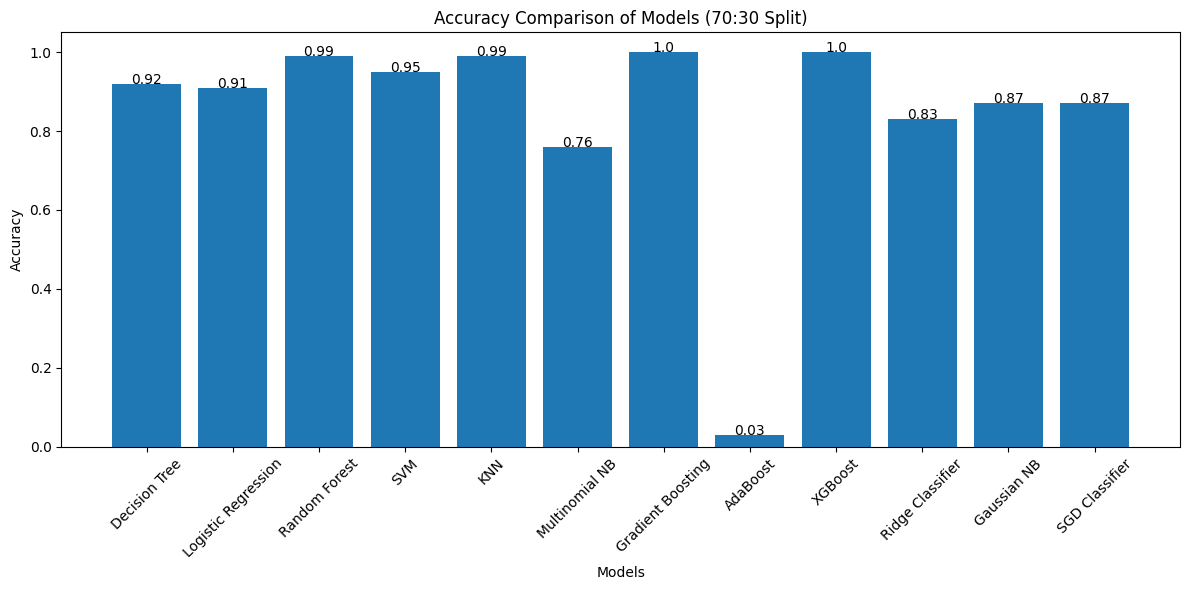

In [153]:
import matplotlib.pyplot as plt

# Model Names
models = [
    "Decision Tree",
    "Logistic Regression",
    "Random Forest",
    "SVM",
    "KNN",
    "Multinomial NB",
    "Gradient Boosting",
    "AdaBoost",
    "XGBoost",
    "Ridge Classifier",
    "Gaussian NB",
    "SGD Classifier"
]

# Accuracy values for 70:30 split
accuracy_70 = [
    0.92,
    0.91,
    0.99,
    0.95,
    0.99,
    0.76,
    1.0,
    0.03,
    1.0,
    0.83,
    0.87,
    0.87

]

# Plot
plt.figure(figsize=(12,6))
plt.bar(models, accuracy_70)

# Labels
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Models (70:30 Split)")

# Rotate labels
plt.xticks(rotation=45)

# Show values on bars
for i, v in enumerate(accuracy_70):
    plt.text(i, v, str(round(v, 2)), ha='center')

plt.tight_layout()
plt.show()

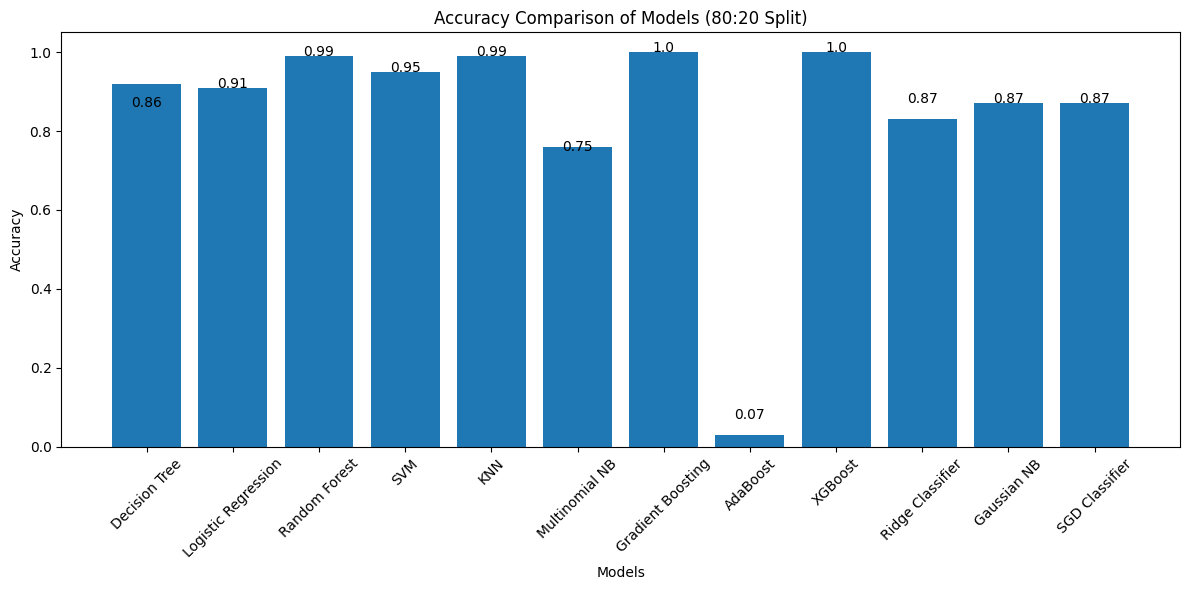

In [154]:
import matplotlib.pyplot as plt

# Model Names
models = [
    "Decision Tree",
    "Logistic Regression",
    "Random Forest",
    "SVM",
    "KNN",
    "Multinomial NB",
    "Gradient Boosting",
    "AdaBoost",
    "XGBoost",
    "Ridge Classifier",
    "Gaussian NB",
    "SGD Classifier"
]

# Accuracy values for 80:20 split
accuracy_80 = [
    0.86,
    0.91,
    0.99,
    0.95,
    0.99,
    0.75,
    1.0,
    0.07,
    1.0,
    0.87,
    0.87,
    0.87

]

# Plot
plt.figure(figsize=(12,6))
plt.bar(models, accuracy_70)

# Labels
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Models (80:20 Split)")

# Rotate labels
plt.xticks(rotation=45)

# Show values on bars
for i, v in enumerate(accuracy_80):
    plt.text(i, v, str(round(v, 2)), ha='center')

plt.tight_layout()
plt.show()